# Seasonly ML Exploration

## Safe and personalised seasonal recipe recommendation

This notebook explores the data, modelling alternatives and evaluation evidence used to
select Seasonly's production recommendation policy. It follows a **read-only evidence
design**: tested application code remains the source of truth for preprocessing, training
and evaluation, while this notebook verifies immutable checksums and turns the resulting
artefacts into explanatory tables and visualisations.

The analysis is based entirely on synthetic interactions. Its results demonstrate
reproducible engineering behaviour, but they do not establish that users will prefer or
benefit from the recommendations in real use.


## 1. Research Question, Scope and Safety Boundary

The practical question is:

> Which ranking method should order recipes that have already passed Seasonly's seasonal,
> dietary and allergen eligibility rules?

This is a **learning-to-rank** problem rather than ordinary classification. Each request
creates a *slate* of eligible recipe candidates for one user and month, and the model must
place the most relevant items near the top. The model is not permitted to decide whether a
recipe is safe.

Seasonly applies four hard constraints before ranking:

1. the recipe and provider must be active;
2. the recipe must contain produce in season for the user's country and month;
3. diet and avoided-food rules must be satisfied;
4. every declared allergen must have a verified `does_not_contain` assessment.

Missing or unknown allergen evidence therefore removes a recipe from the candidate set.
This fail-closed boundary is deliberately independent of model score: a higher predicted
preference can never reintroduce an excluded recipe.

**Section sources:** Seasonly project evidence; Järvelin and Kekäläinen (2002); Burges
(2010).


### 1.1 Reproducible notebook setup

The notebook supports execution from either the repository root or its own `notebooks/`
directory. It resolves that explicit two-location contract, validates every required path
and raises an error if the immutable evidence is unavailable. The large CSV files are never
rewritten, and later cells load only columns needed for the visual analysis.


In [1]:
# pyright: reportAny=false, reportUnknownArgumentType=false, reportUnknownMemberType=false, reportUnknownVariableType=false, reportUnusedCallResult=false
from __future__ import annotations

import hashlib
from pathlib import Path
from typing import ClassVar

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib.ticker import PercentFormatter
from pydantic import BaseModel, ConfigDict, ValidationError

NOTEBOOK_WORKING_DIR = Path.cwd().resolve()
if (NOTEBOOK_WORKING_DIR / "pyproject.toml").is_file():
    repo_root = NOTEBOOK_WORKING_DIR
elif (
    NOTEBOOK_WORKING_DIR.name == "notebooks"
    and (NOTEBOOK_WORKING_DIR.parent / "pyproject.toml").is_file()
):
    repo_root = NOTEBOOK_WORKING_DIR.parent
else:
    raise FileNotFoundError(
        "Run this notebook from the Seasonly repository root or its notebooks directory."
    )

REPO_ROOT = repo_root

DATASET_DIR = REPO_ROOT / "datasets/synthetic/runs/persona-simulation-v2-seed-20260724"
STRESS_DIR = REPO_ROOT / "datasets/synthetic/stress/cold-start-v1-seed-20260725"
ARTIFACT_DIR = REPO_ROOT / "artifacts/recommendations/lightgbm-lambdarank-v1-seed-20260724"

required_paths = [
    DATASET_DIR / "manifest.json",
    DATASET_DIR / "personas.csv",
    DATASET_DIR / "training_examples.csv",
    DATASET_DIR / "baseline_metrics.json",
    STRESS_DIR / "section6_evaluation-v2.json",
    ARTIFACT_DIR / "manifest.json",
    ARTIFACT_DIR / "tuning_results.json",
]
missing_paths = [path for path in required_paths if not path.is_file()]
if missing_paths:
    raise FileNotFoundError(f"Required immutable evidence is missing: {missing_paths}")

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="deep",
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 110,
    },
)

SEASONLY_COLOURS = {
    "green": "#4F772D",
    "sage": "#90A955",
    "brown": "#8B5E3C",
    "gold": "#D4A373",
    "blue": "#4C78A8",
    "orange": "#F58518",
    "red": "#C44E52",
    "grey": "#6B7280",
}

print(f"Repository root: {REPO_ROOT}")
print("Notebook mode: read-only analysis of frozen evidence")

Repository root: /Users/fabietto/Uni-Year3/Final_year_project/Seasonly
Notebook mode: read-only analysis of frozen evidence


## 2. Data Provenance and Integrity

The main simulation contains 500 synthetic adults assigned across 12 personas. Interactions
were generated over 90 chronological days from 453 recipe records. Each displayed recipe
becomes one candidate row, and subsequent opens, favourites and plans are attributed to the
most recent eligible impression within a fixed window.

The generator records its seed, version, file sizes and SHA-256 hashes in a manifest. The
model and evaluation artefacts independently retain the source-manifest hash. These links
make it possible to demonstrate that the figures below describe the exact data used for
fitting and evaluation rather than a later or accidentally modified copy.

Synthetic personas are useful for testing pipelines and controlled cold-start behaviour,
but synthetic outcomes inherit the assumptions of their generating policy (Baumann
*et al.*, 2023). They must not be presented as real-user effectiveness evidence.


In [2]:
# pyright: reportAny=false, reportUnknownArgumentType=false, reportUnknownMemberType=false, reportUnknownVariableType=false, reportUnusedCallResult=false
class EvidenceModel(BaseModel):
    model_config: ClassVar[ConfigDict] = ConfigDict(strict=True, extra="ignore")


class FileEvidence(EvidenceModel):
    sha256: str


class DatasetManifest(EvidenceModel):
    classification: str
    generator_version: str
    seed: int
    days: int
    users: int
    actual_recipe_records: int
    training_examples: int
    events: int
    event_counts: dict[str, int]
    persona_user_counts: dict[str, int]
    files: dict[str, FileEvidence]


class BaselineEvidence(EvidenceModel):
    dataset_manifest_sha256: str


class ArtifactManifest(EvidenceModel):
    classification: str
    synthetic_only: bool
    dataset_manifest_sha256: str
    best_iteration: int
    feature_importance_gain: dict[str, float]
    files: dict[str, FileEvidence]


class TuningConfiguration(EvidenceModel):
    name: str
    num_leaves: int
    min_child_samples: int
    reg_lambda: float


class RankingMetrics(EvidenceModel):
    ndcg_at_k: float
    recall_at_k: float
    catalog_coverage_at_k: float
    mean_ingredient_diversity_at_k: float


class TuningCandidate(EvidenceModel):
    config: TuningConfiguration
    best_iteration: int
    validation_metrics: RankingMetrics


class TuningEvidence(EvidenceModel):
    candidates: list[TuningCandidate]


class RobustnessInputs(EvidenceModel):
    source_dataset_manifest_sha256: str
    model_artifact_manifest_sha256: str


class BootstrapInterval(EvidenceModel):
    mean_delta: float
    lower_95: float
    upper_95: float
    probability_positive: float
    samples: int


class SliceDifference(EvidenceModel):
    ndcg_at_10: float
    recall_at_10: float


class PersonaSlice(EvidenceModel):
    value: str
    eligible_for_interpretation: bool
    lightgbm_minus_seasonal_tfidf: SliceDifference


class SliceEvidence(EvidenceModel):
    persona_key: list[PersonaSlice]


class CohortEvidence(EvidenceModel):
    metrics: dict[str, RankingMetrics]
    lightgbm_minus_seasonal_tfidf: dict[str, BootstrapInterval]


class LockedCohortEvidence(CohortEvidence):
    slices: SliceEvidence


class CoverageCounts(EvidenceModel):
    users_with_candidates: int
    users_without_candidates: int


class SourceAudit(EvidenceModel):
    candidates_checked: int
    violations: int
    users: int
    users_with_candidates: int
    coverage_by_persona: dict[str, CoverageCounts]


class SafetyAudits(EvidenceModel):
    source_candidates: SourceAudit


class RobustnessControls(EvidenceModel):
    safety_audits: SafetyAudits


class DecisionGate(EvidenceModel):
    learned_model_supported_on_both_cohorts: bool
    selected_for_section_7: str


class RobustnessEvidence(EvidenceModel):
    inputs: RobustnessInputs
    locked_test: LockedCohortEvidence
    cold_start_stress: CohortEvidence
    controls: RobustnessControls
    decision_gate: DecisionGate


def read_json[EvidenceT: EvidenceModel](
    path: Path,
    model: type[EvidenceT],
) -> EvidenceT:
    try:
        return model.model_validate_json(path.read_text(encoding="utf-8"))
    except (OSError, ValidationError) as error:
        raise ValueError(f"Could not validate JSON evidence: {path}") from error


def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as input_file:
        for chunk in iter(lambda: input_file.read(65_536), b""):
            digest.update(chunk)
    return digest.hexdigest()


dataset_manifest = read_json(DATASET_DIR / "manifest.json", DatasetManifest)
baseline_evidence = read_json(DATASET_DIR / "baseline_metrics.json", BaselineEvidence)
artifact_manifest = read_json(ARTIFACT_DIR / "manifest.json", ArtifactManifest)
tuning_evidence = read_json(ARTIFACT_DIR / "tuning_results.json", TuningEvidence)
robustness_evidence = read_json(
    STRESS_DIR / "section6_evaluation-v2.json",
    RobustnessEvidence,
)

if dataset_manifest.classification != "synthetic":
    raise ValueError("The notebook accepts only an explicitly synthetic dataset.")
if artifact_manifest.classification != "synthetic_prototype_model":
    raise ValueError("The LightGBM artefact is not classified as a synthetic prototype.")
if artifact_manifest.synthetic_only is not True:
    raise ValueError("The model artefact must retain its synthetic-only restriction.")

dataset_manifest_hash = sha256(DATASET_DIR / "manifest.json")
artifact_manifest_hash = sha256(ARTIFACT_DIR / "manifest.json")

if baseline_evidence.dataset_manifest_sha256 != dataset_manifest_hash:
    raise ValueError("Baseline evidence does not match the frozen dataset manifest.")
if artifact_manifest.dataset_manifest_sha256 != dataset_manifest_hash:
    raise ValueError("Model artefact does not match the frozen dataset manifest.")

robustness_inputs = robustness_evidence.inputs
if robustness_inputs.source_dataset_manifest_sha256 != dataset_manifest_hash:
    raise ValueError("Robustness evidence does not match the source dataset.")
if robustness_inputs.model_artifact_manifest_sha256 != artifact_manifest_hash:
    raise ValueError("Robustness evidence does not match the model artefact.")

dataset_files = dataset_manifest.files
for filename, metadata in dataset_files.items():
    expected_hash = metadata.sha256
    if sha256(DATASET_DIR / filename) != expected_hash:
        raise ValueError(f"Dataset checksum mismatch: {filename}")

artifact_files = artifact_manifest.files
for filename, metadata in artifact_files.items():
    expected_hash = metadata.sha256
    if sha256(ARTIFACT_DIR / filename) != expected_hash:
        raise ValueError(f"Model checksum mismatch: {filename}")

provenance_summary = pd.DataFrame(
    [
        ("Generator", dataset_manifest.generator_version),
        ("Random seed", dataset_manifest.seed),
        ("Simulation days", dataset_manifest.days),
        ("Synthetic users", dataset_manifest.users),
        ("Recipe records", dataset_manifest.actual_recipe_records),
        ("Candidate rows", dataset_manifest.training_examples),
        ("Interaction events", dataset_manifest.events),
        ("LightGBM trees", artifact_manifest.best_iteration),
    ],
    columns=["Evidence item", "Value"],
)
_ = display(provenance_summary.style.hide(axis="index"))
print("All dataset, model and cross-evaluation checksum links verified.")

Evidence item,Value
Generator,persona-simulation-v2
Random seed,20260724
Simulation days,90
Synthetic users,500
Recipe records,453
Candidate rows,314986
Interaction events,434069
LightGBM trees,21


All dataset, model and cross-evaluation checksum links verified.


### Interpretation of provenance checks

The manifest identifies generator `persona-simulation-v2` with seed `20260724`. All five
dataset files and all three model files pass their recorded SHA-256 checks. The baseline,
LightGBM and robustness evidence also point to the same dataset manifest, so the later
comparisons are traceable to one frozen source.

This establishes **reproducibility and integrity**, not ecological validity. The behaviour
of 500 simulated users cannot substitute for observations from real Seasonly users.


## 3. Exploratory Analysis of Personas and Interactions

Personas represent different dietary patterns, cuisine preferences and interaction
tendencies. Their purpose is to exercise recommendation pathways that a small private
pilot could not populate reliably. The first visualisation checks that users are
distributed across the 12 persona definitions and shows the relative frequency of each
generated event type.

Event counts are read from the checksummed manifest rather than loading the 98 MB raw event
file. This is sufficient for distributional reporting and keeps the notebook responsive.


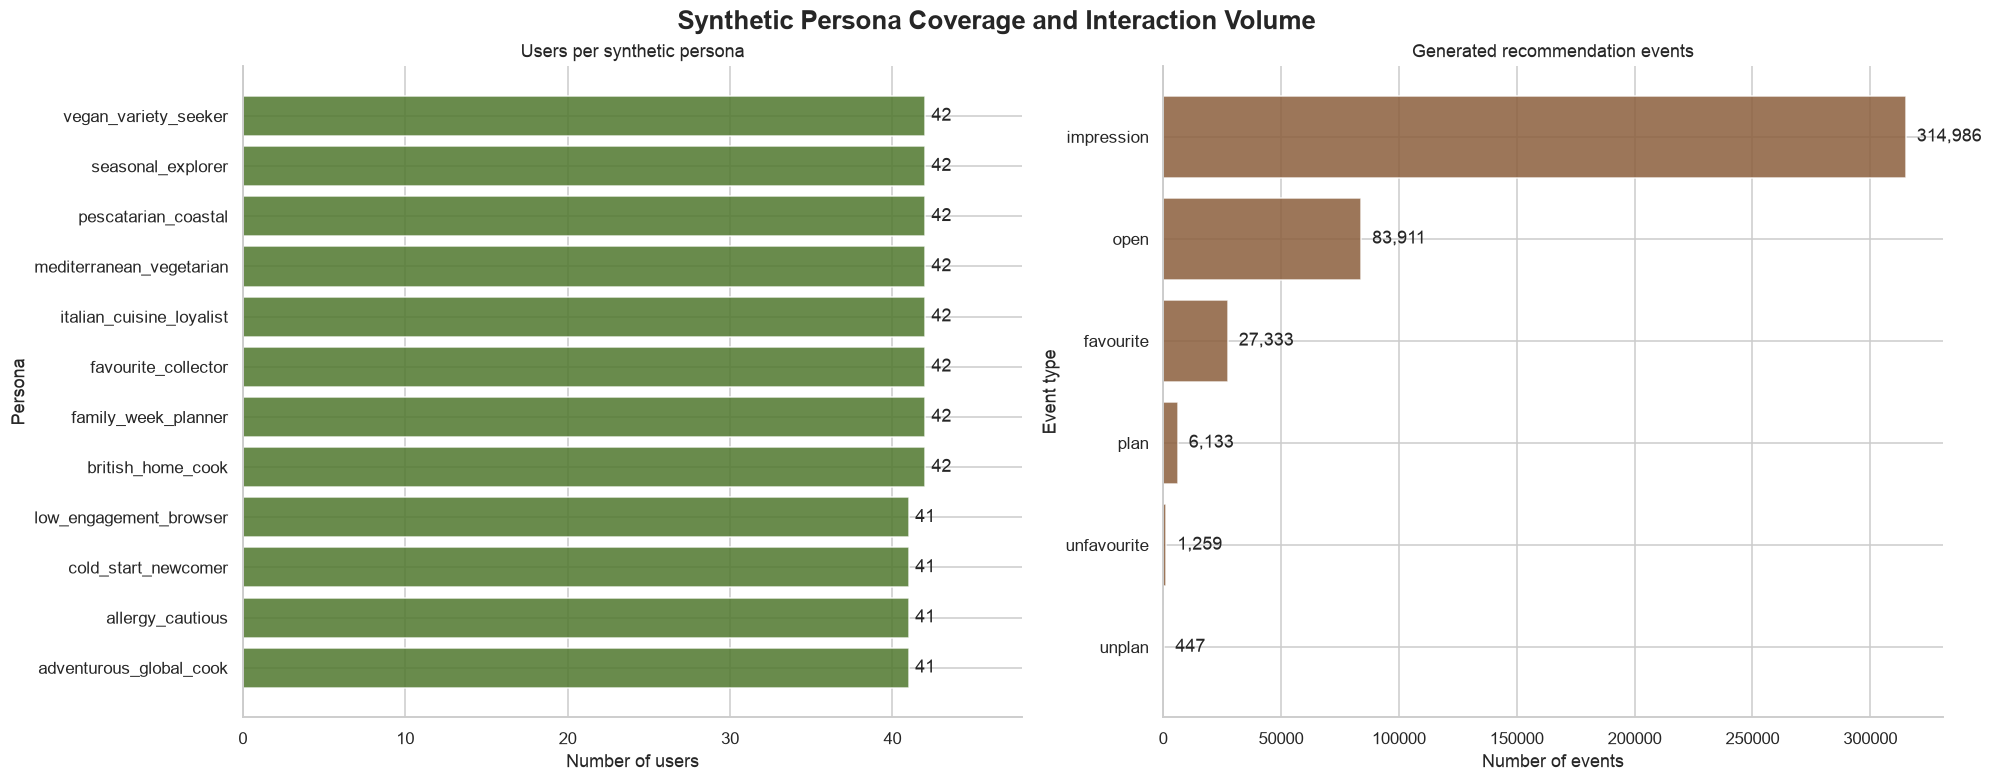

In [3]:
# pyright: reportAny=false, reportUnknownArgumentType=false, reportUnknownMemberType=false, reportUnknownVariableType=false, reportUnusedCallResult=false
persona_counts = (
    pd.Series(dataset_manifest.persona_user_counts, dtype="int64", name="Users")
    .rename_axis("Persona")
    .sort_values()
)
event_counts = (
    pd.Series(dataset_manifest.event_counts, dtype="int64", name="Events")
    .rename_axis("Event")
    .sort_values()
)

persona_values = persona_counts.to_numpy(dtype=np.int64)
event_values = event_counts.to_numpy(dtype=np.int64)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), constrained_layout=True)
fig.suptitle(
    "Synthetic Persona Coverage and Interaction Volume",
    fontsize=17,
    fontweight="bold",
)

axes[0].barh(
    persona_counts.index,
    persona_values,
    color=SEASONLY_COLOURS["green"],
    alpha=0.85,
)
axes[0].set_title("Users per synthetic persona")
axes[0].set_xlabel("Number of users")
axes[0].set_ylabel("Persona")
axes[0].set_xlim(0, int(np.max(persona_values)) + 6)
for index, value in enumerate(persona_values):
    axes[0].text(value + 0.4, index, f"{value:,}", va="center")

axes[1].barh(
    event_counts.index,
    event_values,
    color=SEASONLY_COLOURS["brown"],
    alpha=0.85,
)
axes[1].set_title("Generated recommendation events")
axes[1].set_xlabel("Number of events")
axes[1].set_ylabel("Event type")
event_text_offset = float(np.max(event_values)) * 0.015
for index, value in enumerate(event_values):
    axes[1].text(value + event_text_offset, index, f"{value:,}", va="center")

plt.show()

### Interpretation of persona and event coverage

Each persona contains 41 or 42 users, so no persona dominates the simulation by population.
This balanced assignment supports controlled slice comparisons, although it does not claim
to reproduce the prevalence of these behaviours in the public.

Impressions are necessarily the largest event class because every displayed candidate
creates one impression. Opens are more frequent than favourites and plans, while removal
events are comparatively rare. This imbalance is expected for implicit-feedback systems:
the absence of an action is not equivalent to explicit dislike, and stronger actions should
therefore receive greater relevance weight.


## 4. Preprocessing and Leakage Prevention

A random row split would be inappropriate because the same user's future behaviour could
influence features attached to earlier slates. Seasonly instead uses a chronological
70:15:15 division:

- days 1–63: model fitting;
- days 64–76: validation, hyperparameter selection and early stopping;
- days 77–90: one locked test evaluation.

Every historical feature is captured immediately before the current slate. The categorical
encoder is fitted only on training rows, and unseen validation or test categories receive
the explicit missing-category code `−1`. Persona key, position, synthetic markers and
outcome labels are prohibited model features. These controls reduce temporal, target and
identity leakage (Kaufman *et al.*, 2012).

The relevance label reflects the strongest attributed action:

$$
y =
\begin{cases}
3 & \text{planned}\\
2 & \text{favourited}\\
1 & \text{opened}\\
0 & \text{impression only}
\end{cases}
$$


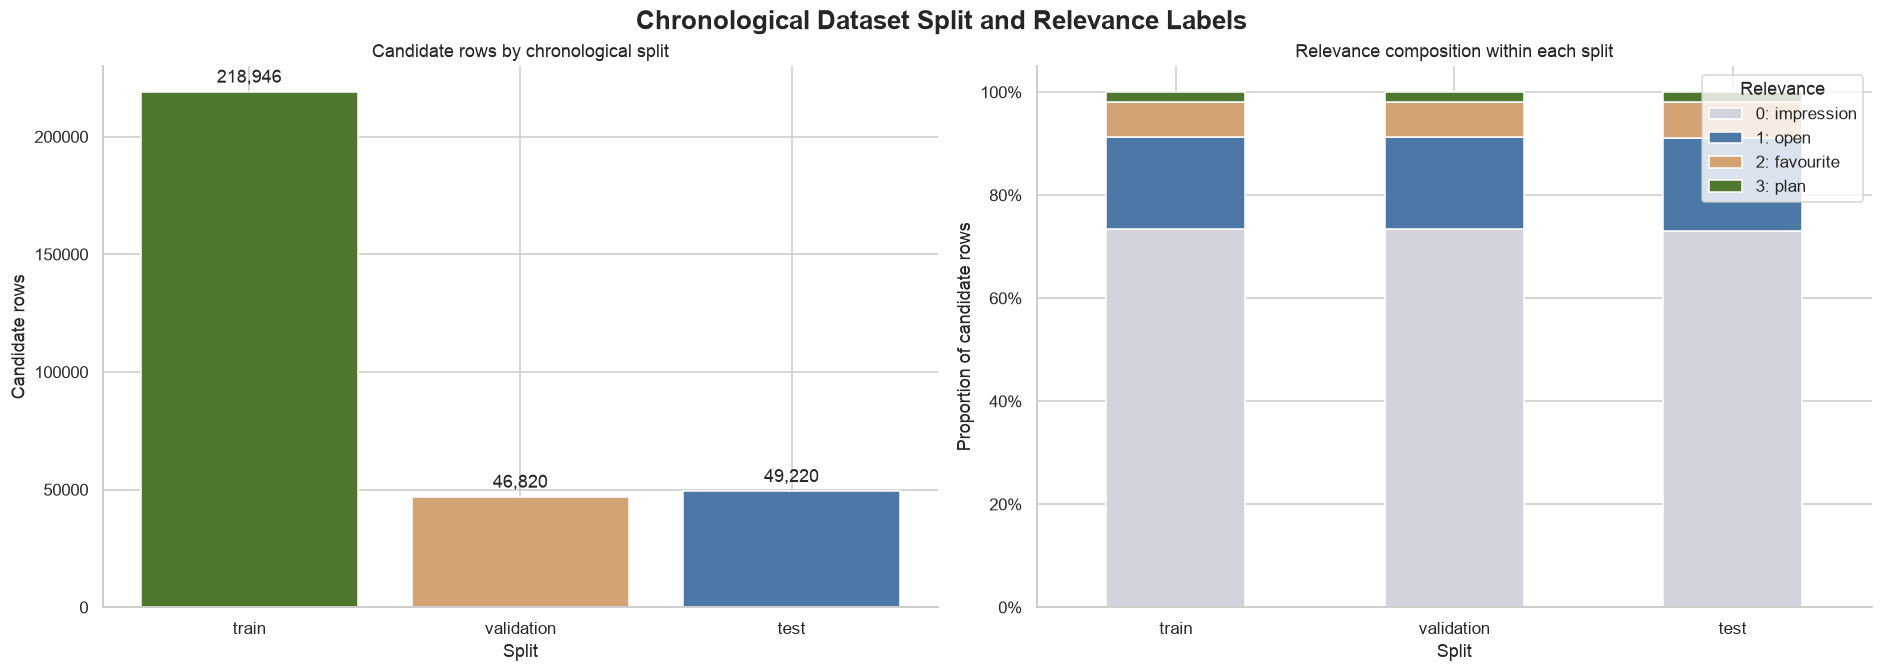

Analysis DataFrame memory: 15.0 MiB


In [4]:
# pyright: reportAny=false, reportUnknownArgumentType=false, reportUnknownMemberType=false, reportUnknownVariableType=false, reportUnusedCallResult=false
analysis_columns = [
    "split",
    "persona_key",
    "relevance",
    "month",
    "seasonal_match_count",
    "cuisine_match",
    "user_country",
    "user_diet",
    "recipe_area",
    "recipe_category",
    "user_prior_impressions",
    "user_prior_opens",
    "user_prior_favourites",
    "user_prior_plans",
    "user_recipe_prior_impressions",
    "recipe_prior_impressions",
    "recipe_prior_positive_actions",
]
categorical_columns = [
    "split",
    "persona_key",
    "user_country",
    "user_diet",
    "recipe_area",
    "recipe_category",
]
integer_columns = [column for column in analysis_columns if column not in categorical_columns]
analysis_dtypes = {
    **{column: "category" for column in categorical_columns},
    **{column: "int32" for column in integer_columns},
}

examples = pd.read_csv(
    DATASET_DIR / "training_examples.csv",
    usecols=analysis_columns,
    dtype=analysis_dtypes,
)
if len(examples) != dataset_manifest.training_examples:
    raise ValueError("Loaded candidate count does not match the manifest.")

split_order = ["train", "validation", "test"]
split_counts = examples["split"].value_counts().reindex(split_order)
relevance_by_split = (
    pd.crosstab(examples["split"], examples["relevance"], normalize="index")
    .reindex(split_order)
    .reindex(columns=[0, 1, 2, 3], fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(17, 6), constrained_layout=True)
fig.suptitle(
    "Chronological Dataset Split and Relevance Labels",
    fontsize=17,
    fontweight="bold",
)

split_colours = [
    SEASONLY_COLOURS["green"],
    SEASONLY_COLOURS["gold"],
    SEASONLY_COLOURS["blue"],
]
axes[0].bar(split_counts.index, split_counts.values, color=split_colours)
axes[0].set_title("Candidate rows by chronological split")
axes[0].set_xlabel("Split")
axes[0].set_ylabel("Candidate rows")
for index, value in enumerate(split_counts.values):
    axes[0].text(index, value + 4_000, f"{value:,}", ha="center")

relevance_colours = [
    "#D1D5DB",
    SEASONLY_COLOURS["blue"],
    SEASONLY_COLOURS["gold"],
    SEASONLY_COLOURS["green"],
]
relevance_by_split.plot(
    kind="bar",
    stacked=True,
    color=relevance_colours,
    ax=axes[1],
)
axes[1].set_title("Relevance composition within each split")
axes[1].set_xlabel("Split")
axes[1].set_ylabel("Proportion of candidate rows")
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(
    title="Relevance",
    labels=["0: impression", "1: open", "2: favourite", "3: plan"],
    loc="upper right",
)

plt.show()

print(f"Analysis DataFrame memory: {examples.memory_usage(deep=True).sum() / 1_048_576:.1f} MiB")

### Interpretation of preprocessing evidence

The split contains 218,946 training candidates, 46,820 validation candidates and 49,220
locked-test candidates, matching the manifest exactly. The relative relevance composition
is stable across time, but relevance zero is the majority class because most impressions
do not produce a later action.

The split is performed by event time before encoding or model fitting. Consequently, a
future action cannot change an earlier row's historical features, and validation/test
categories cannot define the training vocabulary.


### 4.1 Numerical feature behaviour

The model combines current-context features with historical counts. Count variables are
right-skewed as users and recipes accumulate interactions over time, so the graphs display
them on a $\log(1+x)$ scale. This transformation is for visualisation only; the stored
LightGBM features retain their original counts.


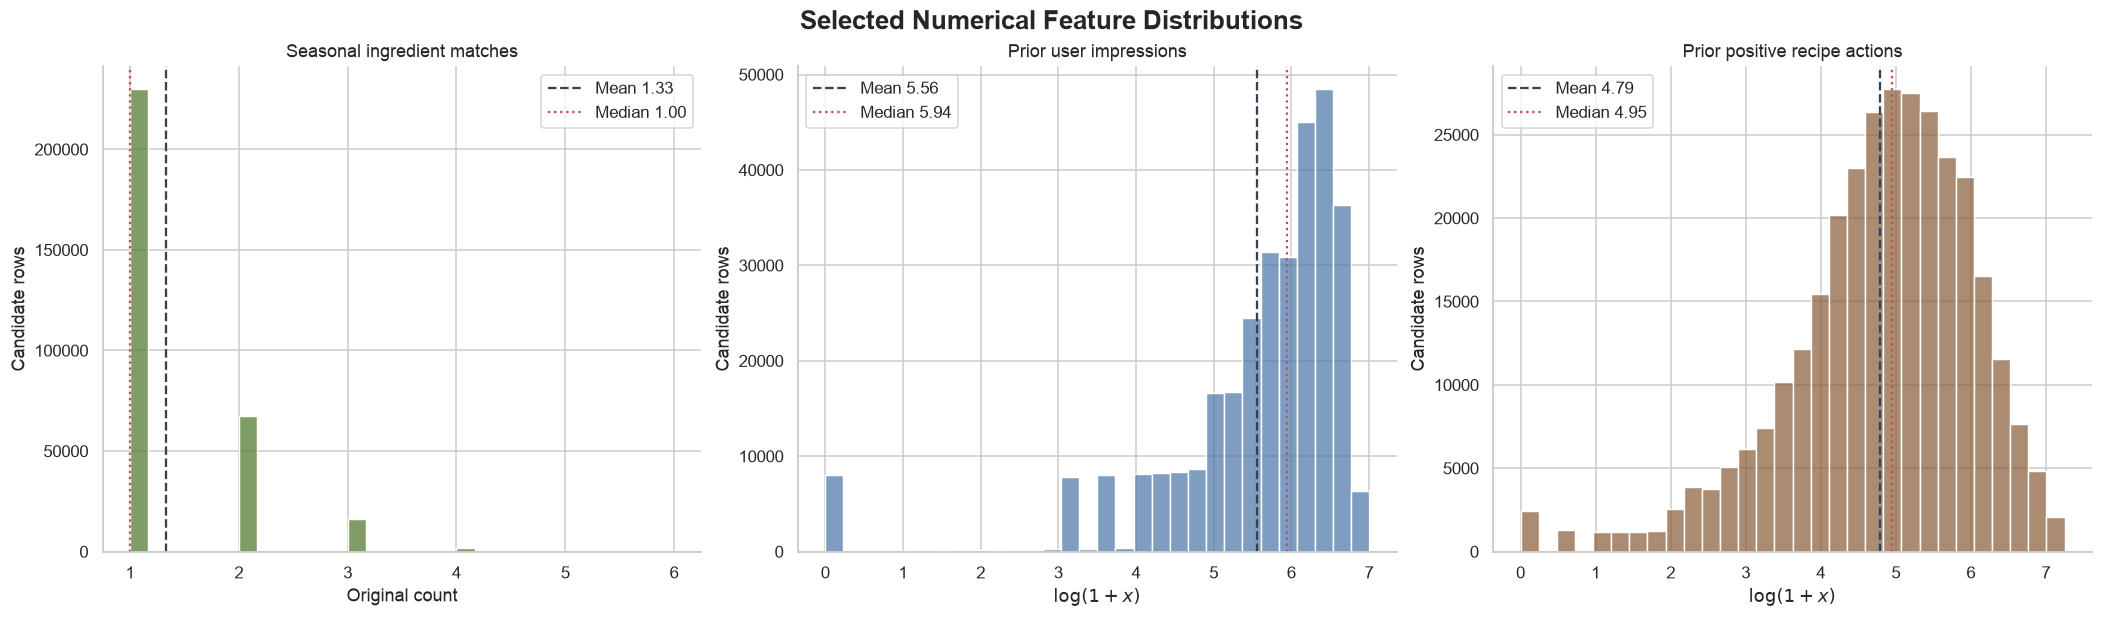

In [5]:
# pyright: reportAny=false, reportUnknownArgumentType=false, reportUnknownMemberType=false, reportUnknownVariableType=false, reportUnusedCallResult=false
feature_plots = [
    (
        "seasonal_match_count",
        "Seasonal ingredient matches",
        "Original count",
        False,
        SEASONLY_COLOURS["green"],
    ),
    (
        "user_prior_impressions",
        "Prior user impressions",
        r"$\log(1+x)$",
        True,
        SEASONLY_COLOURS["blue"],
    ),
    (
        "recipe_prior_positive_actions",
        "Prior positive recipe actions",
        r"$\log(1+x)$",
        True,
        SEASONLY_COLOURS["brown"],
    ),
]

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5), constrained_layout=True)
fig.suptitle(
    "Selected Numerical Feature Distributions",
    fontsize=17,
    fontweight="bold",
)

for axis, (column, title, x_label, log_transform, colour) in zip(
    axes,
    feature_plots,
    strict=True,
):
    values = examples[column].to_numpy(dtype=np.float64)
    displayed_values = np.log1p(values) if log_transform else values
    sns.histplot(
        displayed_values,
        bins=30,
        color=colour,
        alpha=0.72,
        ax=axis,
    )
    mean_value = float(np.mean(displayed_values))
    median_value = float(np.median(displayed_values))
    axis.axvline(mean_value, color="#374151", linestyle="--", label=f"Mean {mean_value:.2f}")
    axis.axvline(
        median_value,
        color=SEASONLY_COLOURS["red"],
        linestyle=":",
        label=f"Median {median_value:.2f}",
    )
    axis.set_title(title)
    axis.set_xlabel(x_label)
    axis.set_ylabel("Candidate rows")
    axis.legend()

plt.show()

### Interpretation of selected features

Seasonal match counts remain small and discrete because they count ingredients matching a
country-month produce table. Historical interaction counts are strongly right-skewed:
established users and frequently displayed recipes accumulate much more evidence than
newcomers or less exposed recipes.

LightGBM can represent non-linear thresholds in these counts without manual scaling.
However, popularity-related history can also encode exposure bias, which is one reason a
transparent content model and a dedicated zero-history cohort are retained.


---

## 5. Candidate Models Before Selection

Three models are considered before choosing the production policy. They progress from a
non-personalised benchmark, through an interpretable content model, to a trained
learning-to-rank model.

### 5.1 Weighted popularity

The popularity score is the training-period relevance accumulated by recipe $r$:

$$
s_{\mathrm{pop}}(r)=\sum_{i \in \mathcal{D}_{\mathrm{train}}}
\mathbb{1}(r_i=r)y_i
$$

It is reproducible and useful as a minimum benchmark, but it favours already exposed
recipes and does not model current season, cuisine or individual history.

### 5.2 Seasonal TF-IDF content ranking

Each recipe is treated as a document containing prefixed name, cuisine, category and
ingredient tokens. For term $t$ and recipe document $d$:

$$
\operatorname{tfidf}(t,d)=\operatorname{tf}(t,d)
\left[\log\left(\frac{1+N}{1+\operatorname{df}(t)}\right)+1\right]
$$

A consented user profile is the normalised relevance-weighted sum of previously positive
recipe vectors:

$$
\mathbf{p}_u=
\frac{\sum_{r \in H_u}w_{ur}\mathbf{v}_r}
{\left\|\sum_{r \in H_u}w_{ur}\mathbf{v}_r\right\|_2}
$$

Content similarity is the cosine of the user and candidate vectors:

$$
\operatorname{sim}(u,r)=
\frac{\mathbf{p}_u \cdot \mathbf{v}_r}
{\|\mathbf{p}_u\|_2\|\mathbf{v}_r\|_2}
$$

Seasonly's final transparent score is:

$$
s_{\mathrm{TFIDF}}(u,r)=
0.60\,\operatorname{sim}(u,r)
+0.30\frac{m_r}{m_r+1}
+0.10c_{ur}
$$

where $m_r$ is the seasonal match count and $c_{ur}\in\{0,1\}$ is a cuisine match. When
consented history is unavailable, similarity is zero and the same policy provides
deterministic cold-start ranking.

### 5.3 LightGBM LambdaRank

LambdaRank learns a scoring function $f_\theta(\mathbf{x}_{ur})$ for candidate features
within a slate. Candidate pairs with different relevance labels contribute logistic
gradients weighted by the magnitude of the NDCG change caused by swapping their positions:

$$
P_{ij}=\frac{1}{1+\exp[-\sigma(s_i-s_j)]},
\qquad
|\lambda_{ij}| \propto |\Delta\operatorname{NDCG}_{ij}|
$$

Gradient-boosted trees can capture non-linear interactions among season, cuisine,
country, diet and historical counts. This additional flexibility is justified only if it
improves robust held-out ranking enough to offset dependency, monitoring and explanation
costs (Burges, 2010; Ke *et al.*, 2017).


## 6. Evaluation Measures

Model selection must reflect ranking quality rather than ordinary classification accuracy.

For ranked relevances $rel_i$, discounted cumulative gain at cutoff $k$ is:

$$
\operatorname{DCG}@k =
\sum_{i=1}^{k}\frac{2^{rel_i}-1}{\log_2(i+1)}
$$

Normalised DCG divides observed DCG by the best possible ordering for the same slate:

$$
\operatorname{NDCG}@k =
\frac{\operatorname{DCG}@k}{\operatorname{IDCG}@k}
$$

Recall measures how many relevant candidates appear in the first $k$ positions:

$$
\operatorname{Recall}@k =
\frac{|\{\text{relevant items}\}\cap\{\text{top-}k\}|}
{|\{\text{relevant items}\}|}
$$

Catalogue coverage records the fraction of recipes appearing in any top-$k$ list.
Ingredient diversity uses mean pairwise Jaccard distance:

$$
d_J(A,B)=1-\frac{|A\cap B|}{|A\cup B|}
$$

NDCG and Recall are averaged only across slates with at least one relevant candidate;
coverage and diversity use every slate. NDCG is the primary relevance criterion, while the
other measures prevent a narrow accuracy-only interpretation (Järvelin and Kekäläinen,
2002).


## 7. LightGBM Training and Validation Evidence

Four predefined configurations vary tree capacity, minimum child size and L2
regularisation. Every candidate uses the LambdaRank objective, learning rate 0.05, at most
500 boosting rounds and 30-round early stopping. Configuration selection uses validation
NDCG@10 only; the locked test is evaluated once after selection.


Configuration,Leaves,Minimum child samples,L2 regularisation,Best iteration,Validation NDCG@10,Validation Recall@10,Catalogue coverage@10
leaves31_child250_l2_1,31,250,1.0,21,0.3668,0.5297,0.9470
leaves31_child100_l2_1,31,100,1.0,2,0.3657,0.5225,0.8830
leaves15_child100_l2_1,15,100,1.0,1,0.3648,0.5243,0.8278
leaves63_child250_l2_2,63,250,2.0,2,0.3627,0.5200,0.9272


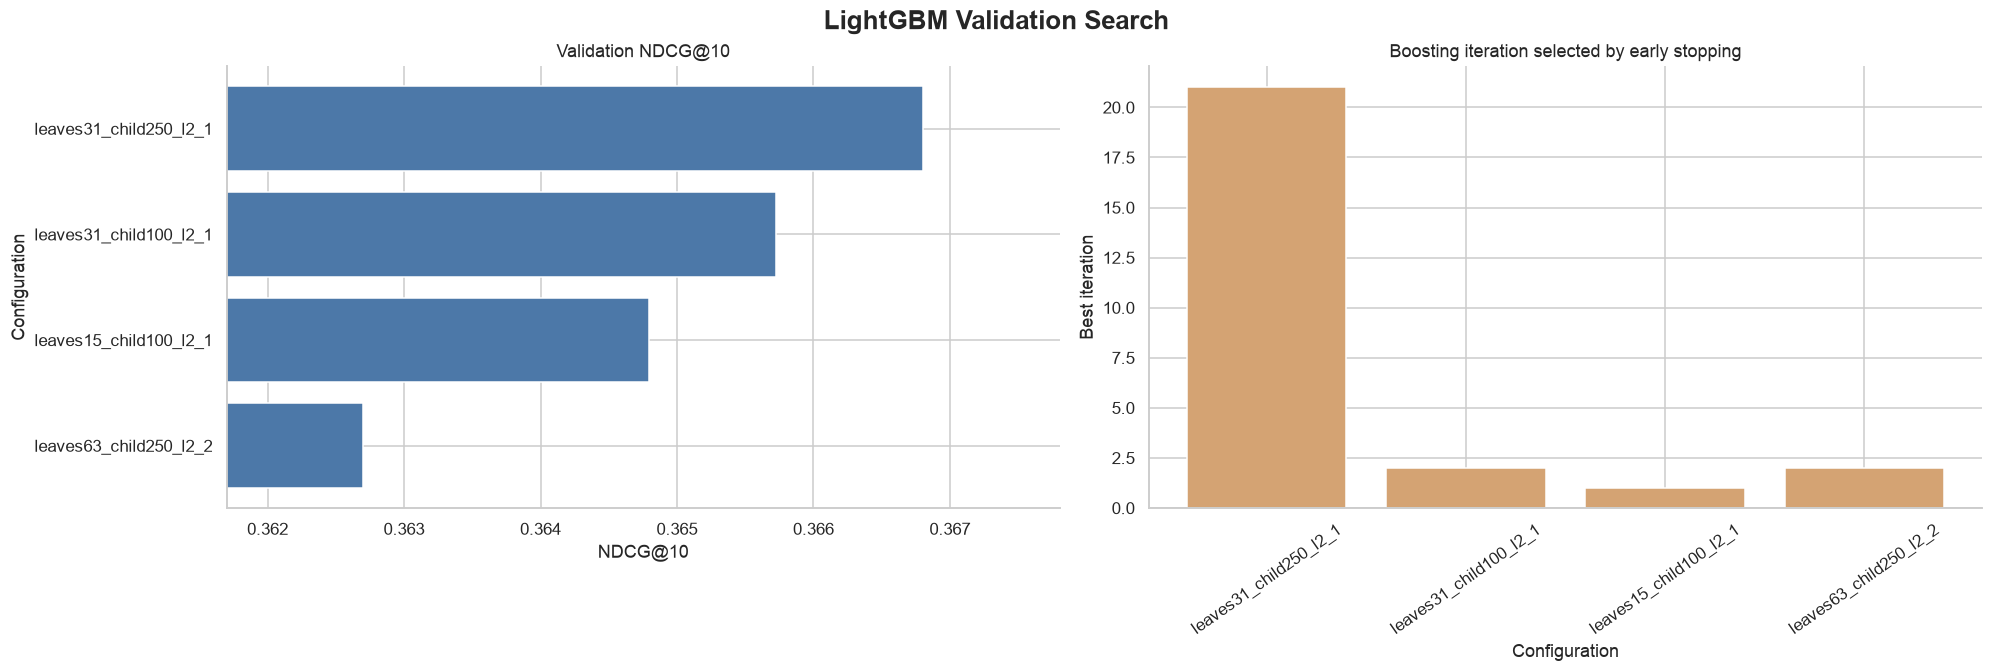

In [6]:
# pyright: reportAny=false, reportUnknownArgumentType=false, reportUnknownMemberType=false, reportUnknownVariableType=false, reportUnusedCallResult=false
tuning_records: list[dict[str, str | int | float]] = []
for candidate in tuning_evidence.candidates:
    config = candidate.config
    metrics = candidate.validation_metrics
    tuning_records.append(
        {
            "Configuration": config.name,
            "Leaves": config.num_leaves,
            "Minimum child samples": config.min_child_samples,
            "L2 regularisation": config.reg_lambda,
            "Best iteration": candidate.best_iteration,
            "Validation NDCG@10": metrics.ndcg_at_k,
            "Validation Recall@10": metrics.recall_at_k,
            "Catalogue coverage@10": metrics.catalog_coverage_at_k,
        }
    )

tuning_df = (
    pd.DataFrame(tuning_records)
    .sort_values("Validation NDCG@10", ascending=False)
    .reset_index(drop=True)
)
_ = display(
    tuning_df.style.hide(axis="index").format(
        {
            "L2 regularisation": "{:.1f}",
            "Validation NDCG@10": "{:.4f}",
            "Validation Recall@10": "{:.4f}",
            "Catalogue coverage@10": "{:.4f}",
        }
    )
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)
fig.suptitle(
    "LightGBM Validation Search",
    fontsize=17,
    fontweight="bold",
)

ordered_tuning = tuning_df.sort_values("Validation NDCG@10")
axes[0].barh(
    ordered_tuning["Configuration"],
    ordered_tuning["Validation NDCG@10"],
    color=SEASONLY_COLOURS["blue"],
)
axes[0].set_title("Validation NDCG@10")
axes[0].set_xlabel("NDCG@10")
axes[0].set_ylabel("Configuration")
axes[0].set_xlim(
    ordered_tuning["Validation NDCG@10"].min() - 0.001,
    ordered_tuning["Validation NDCG@10"].max() + 0.001,
)

axes[1].bar(
    tuning_df["Configuration"],
    tuning_df["Best iteration"],
    color=SEASONLY_COLOURS["gold"],
)
axes[1].set_title("Boosting iteration selected by early stopping")
axes[1].set_xlabel("Configuration")
axes[1].set_ylabel("Best iteration")
axes[1].tick_params(axis="x", rotation=35)

plt.show()

### Interpretation of LightGBM tuning

The selected configuration uses 31 leaves, a minimum of 250 examples per child and L2
regularisation of 1.0. Early stopping retains 21 trees. It achieves validation NDCG@10 of
approximately 0.3668, only slightly above the remaining configurations.

The search is deliberately small and predetermined. Expanding it after observing locked
test results would turn the test set into an implicit validation set and weaken the
generalisation claim.


### 7.1 Feature-gain importance

LightGBM's gain importance sums the training-objective reduction attributed to splits on
each feature. It describes how this particular fitted model constructed its trees; it does
not show that a feature *causes* preference and it can favour variables with more available
split points.


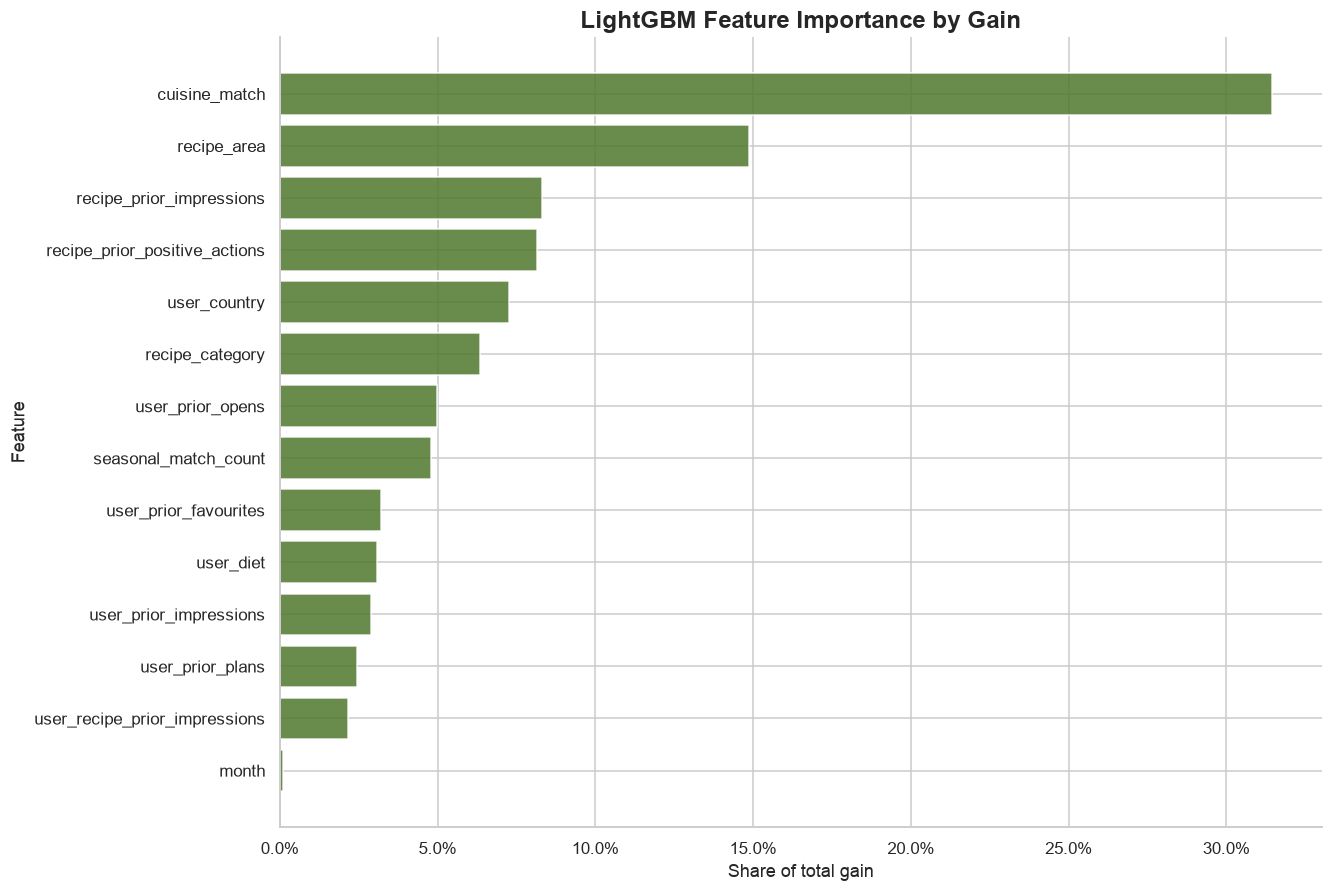

Feature,Gain,Gain_share
cuisine_match,"2,941.97",31.45%
recipe_area,"1,391.84",14.88%
recipe_prior_impressions,777.73,8.31%
recipe_prior_positive_actions,762.10,8.15%
user_country,678.73,7.26%
recipe_category,594.06,6.35%
user_prior_opens,464.85,4.97%
seasonal_match_count,447.77,4.79%


In [7]:
# pyright: reportAny=false, reportUnknownArgumentType=false, reportUnknownMemberType=false, reportUnknownVariableType=false, reportUnusedCallResult=false
raw_importance = artifact_manifest.feature_importance_gain
importance_df = pd.DataFrame(
    {
        "Feature": list(raw_importance),
        "Gain": list(raw_importance.values()),
    }
)
total_gain = float(importance_df["Gain"].sum())
if total_gain <= 0:
    raise ValueError("Model feature importance must have positive total gain.")
importance_df["Gain_share"] = importance_df["Gain"] / total_gain
importance_df = importance_df.sort_values("Gain_share")

fig, axis = plt.subplots(figsize=(12, 8), constrained_layout=True)
axis.barh(
    importance_df["Feature"],
    importance_df["Gain_share"],
    color=SEASONLY_COLOURS["green"],
    alpha=0.85,
)
axis.set_title(
    "LightGBM Feature Importance by Gain",
    fontsize=16,
    fontweight="bold",
)
axis.set_xlabel("Share of total gain")
axis.set_ylabel("Feature")
axis.xaxis.set_major_formatter(PercentFormatter(1))
plt.show()

display(
    importance_df.sort_values("Gain_share", ascending=False)
    .head(8)
    .style.hide(axis="index")
    .format({"Gain": "{:,.2f}", "Gain_share": "{:.2%}"})
)

### Interpretation of feature importance

Cuisine match contributes the largest recorded gain, followed by recipe area, global recipe
history, user country and recipe category. The model therefore relies on both contextual
compatibility and accumulated exposure signals.

This pattern is plausible for the generating personas, but it also demonstrates why the
result must remain synthetic-only. Persona rules directly influence cuisine and action
probabilities, so importance partly reflects simulation design rather than discovered
human behaviour.


---

## 8. Locked-Test and Cold-Start Comparison

The locked test compares the three ranking strategies on days 77–90. A separate
evaluation-only stress cohort then creates 1,000 new users with zero personal history.
Their global recipe-history features are frozen at the original training cutoff, and their
identifiers do not overlap the source data.

The stress cohort may be evaluated but is prohibited from fitting, tuning or early
stopping. This separation tests whether a model choice based on established synthetic users
remains credible for first-session recommendations.


Cohort,Model,Catalogue coverage@10,Ingredient diversity@10,NDCG@10,Recall@10
Cold-start stress,LightGBM LambdaRank,0.7174,0.9142,0.3383,0.5163
Cold-start stress,Seasonal TF-IDF,0.6865,0.9141,0.3313,0.5099
Cold-start stress,Weighted popularity,0.6071,0.9250,0.3266,0.5215
Locked test,LightGBM LambdaRank,0.9338,0.9168,0.3668,0.5273
Locked test,Seasonal TF-IDF,0.9029,0.9016,0.3655,0.5276
Locked test,Weighted popularity,0.6667,0.9299,0.3487,0.5214


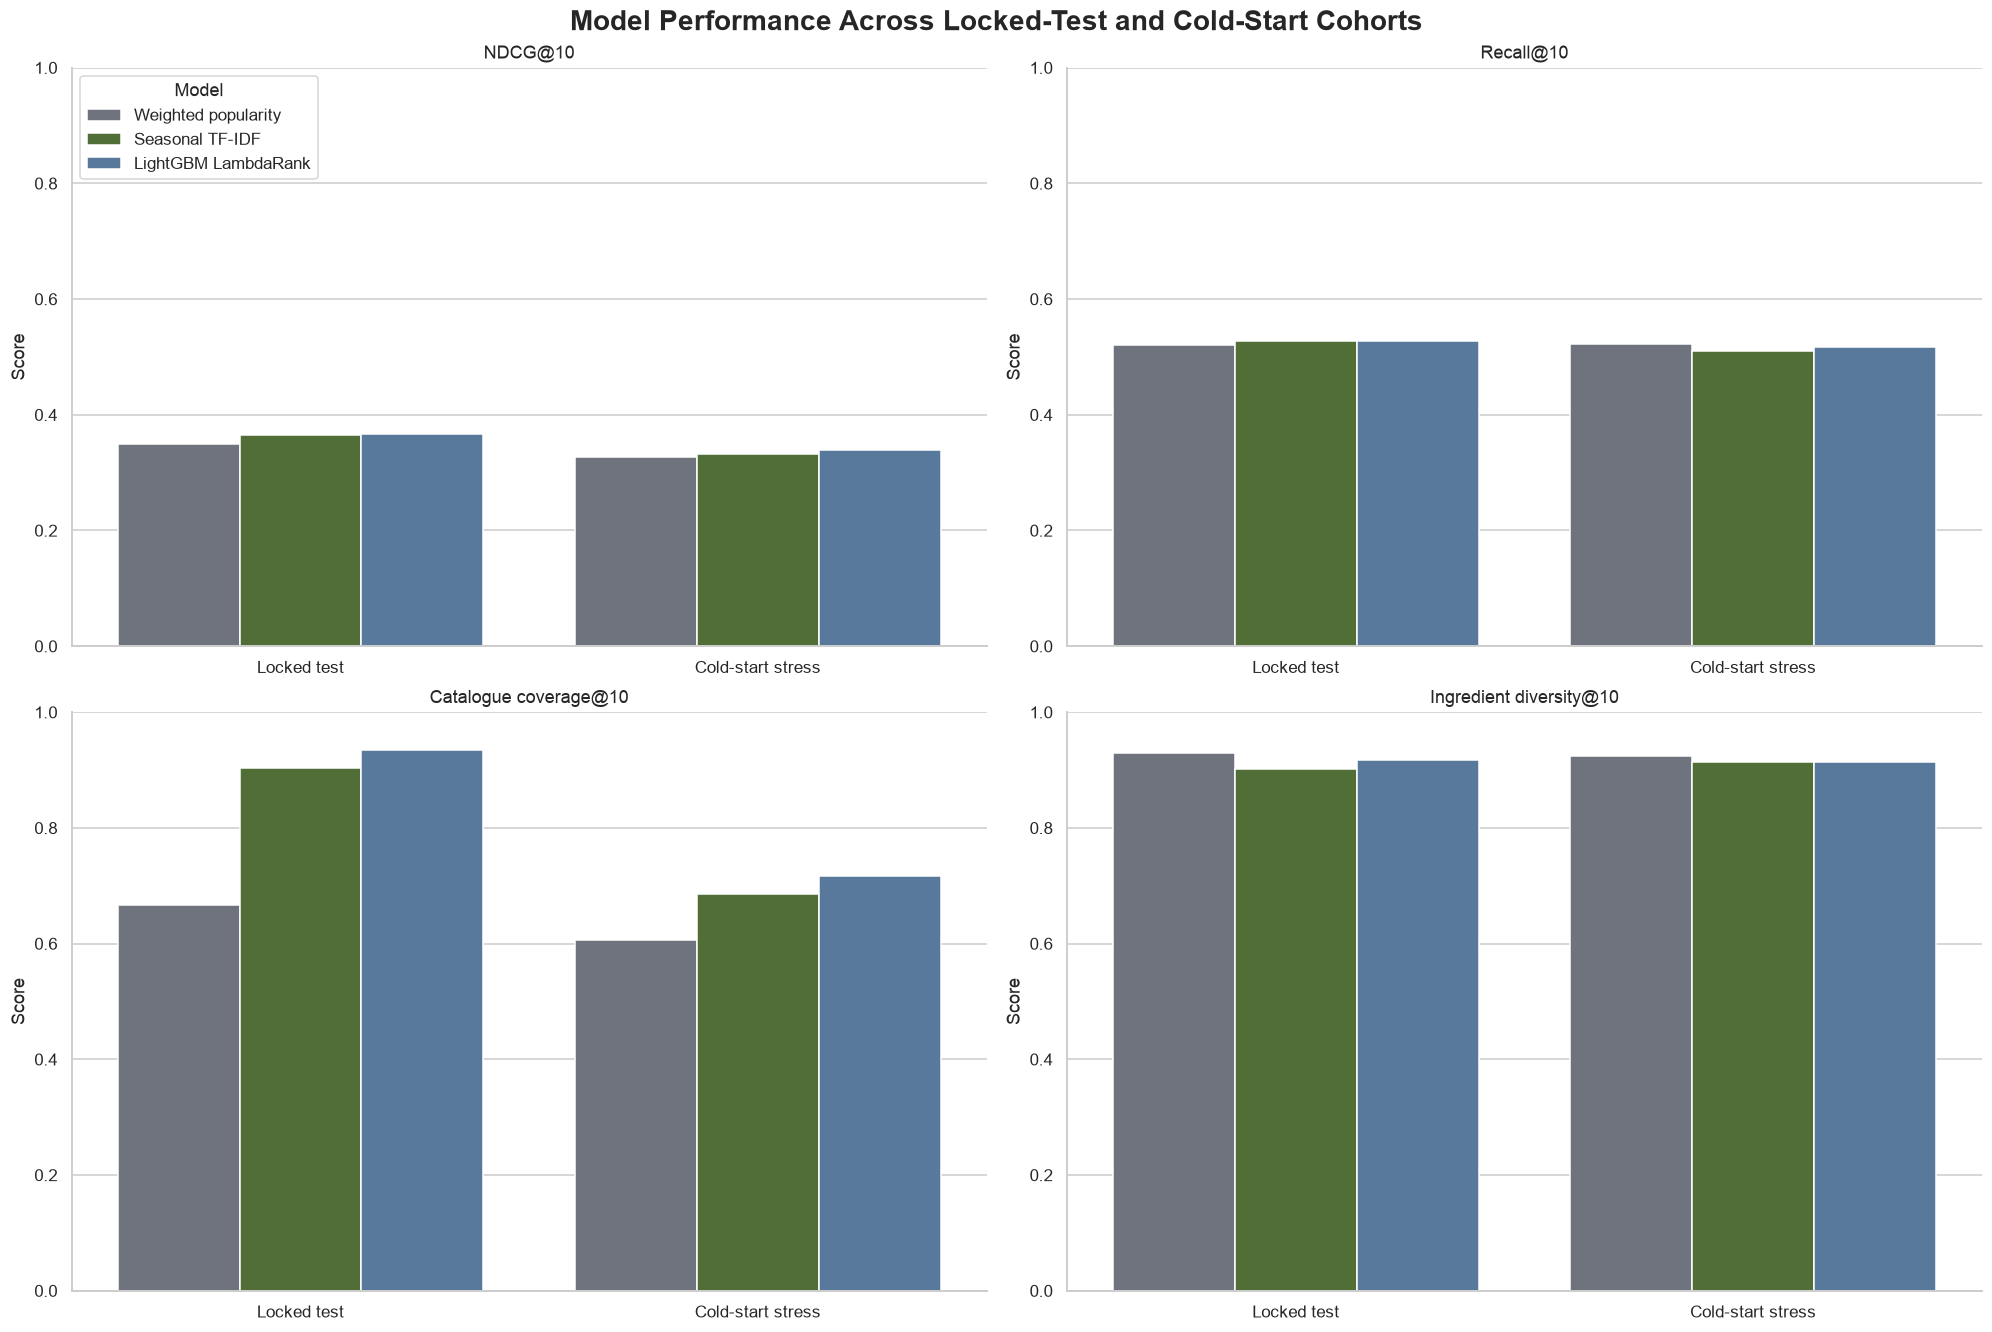

In [8]:
# pyright: reportAny=false, reportUnknownArgumentType=false, reportUnknownMemberType=false, reportUnknownVariableType=false, reportUnusedCallResult=false
model_labels = {
    "weighted_popularity": "Weighted popularity",
    "seasonal_tfidf_content": "Seasonal TF-IDF",
    "lightgbm_lambdarank": "LightGBM LambdaRank",
}
cohort_labels = {
    "locked_test": "Locked test",
    "cold_start_stress": "Cold-start stress",
}
cohort_evidence = {
    "locked_test": robustness_evidence.locked_test,
    "cold_start_stress": robustness_evidence.cold_start_stress,
}
metric_labels = {
    "ndcg_at_k": "NDCG@10",
    "recall_at_k": "Recall@10",
    "catalog_coverage_at_k": "Catalogue coverage@10",
    "mean_ingredient_diversity_at_k": "Ingredient diversity@10",
}

metric_records: list[dict[str, str | float]] = []
for cohort_key, cohort_label in cohort_labels.items():
    cohort_metrics = cohort_evidence[cohort_key].metrics
    for model_key, model_label in model_labels.items():
        model_metrics = cohort_metrics[model_key]
        metric_values = {
            "ndcg_at_k": model_metrics.ndcg_at_k,
            "recall_at_k": model_metrics.recall_at_k,
            "catalog_coverage_at_k": model_metrics.catalog_coverage_at_k,
            "mean_ingredient_diversity_at_k": (model_metrics.mean_ingredient_diversity_at_k),
        }
        for metric_key, metric_label in metric_labels.items():
            metric_records.append(
                {
                    "Cohort": cohort_label,
                    "Model": model_label,
                    "Metric": metric_label,
                    "Value": metric_values[metric_key],
                }
            )

metrics_df = pd.DataFrame(metric_records)
metrics_table = metrics_df.pivot(
    index=["Cohort", "Model"],
    columns="Metric",
    values="Value",
).reset_index()
_ = display(
    metrics_table.style.hide(axis="index").format(
        {label: "{:.4f}" for label in metric_labels.values()}
    )
)

palette = {
    "Weighted popularity": SEASONLY_COLOURS["grey"],
    "Seasonal TF-IDF": SEASONLY_COLOURS["green"],
    "LightGBM LambdaRank": SEASONLY_COLOURS["blue"],
}

fig, axes = plt.subplots(2, 2, figsize=(18, 12), constrained_layout=True)
fig.suptitle(
    "Model Performance Across Locked-Test and Cold-Start Cohorts",
    fontsize=18,
    fontweight="bold",
)

for axis, metric_label in zip(axes.flat, metric_labels.values(), strict=True):
    subset = metrics_df[metrics_df["Metric"] == metric_label]
    sns.barplot(
        data=subset,
        x="Cohort",
        y="Value",
        hue="Model",
        hue_order=list(model_labels.values()),
        palette=palette,
        errorbar=None,
        ax=axis,
    )
    axis.set_title(metric_label)
    axis.set_xlabel("")
    axis.set_ylabel("Score")
    axis.set_ylim(0, 1)
    if axis is not axes[0, 0]:
        axis.get_legend().remove()

axes[0, 0].legend(title="Model", loc="upper left")
plt.show()

### Interpretation of cohort performance

On the locked test, LightGBM has the highest point NDCG, catalogue coverage and ingredient
diversity. Seasonal TF-IDF has marginally higher Recall than LightGBM. The absolute
relevance differences are small: LightGBM NDCG@10 is 0.3668 compared with 0.3655 for
TF-IDF.

LightGBM also has the highest cold-start point NDCG, while weighted popularity has the
highest cold-start Recall. Point estimates alone do not establish that these differences
would persist under another sample, so uncertainty must be evaluated before model choice.


## 9. Paired Bootstrap Uncertainty

Both models rank the same candidates for the same slates, so the analysis computes a
within-slate difference and resamples those paired differences 10,000 times. If
$\Delta_i=m_{L,i}-m_{T,i}$ is the LightGBM-minus-TF-IDF metric difference for slate $i$,
bootstrap replicate $b$ is:

$$
\bar{\Delta}^{*(b)}
=\frac{1}{n}\sum_{j=1}^{n}\Delta_{I^{*(b)}_j}
$$

where the indices $I^{*(b)}_j$ are sampled with replacement. The 2.5th and 97.5th
percentiles form the reported 95% interval (Efron and Tibshirani, 1993).

Seasonly's predefined gate selects LightGBM only if the lower 95% NDCG bound is above zero
on both the locked test and cold-start cohort.


Cohort,Metric,Mean difference,Lower 95%,Upper 95%,Positive resamples,Paired slates
Locked test,NDCG@10,+0.00124,-0.00618,+0.00856,63.18%,"2,443"
Locked test,Recall@10,-0.00028,-0.01002,+0.00914,47.87%,"2,443"
Cold-start stress,NDCG@10,+0.00692,-0.00712,+0.02027,83.54%,986
Cold-start stress,Recall@10,+0.00648,-0.01570,+0.02811,71.84%,986


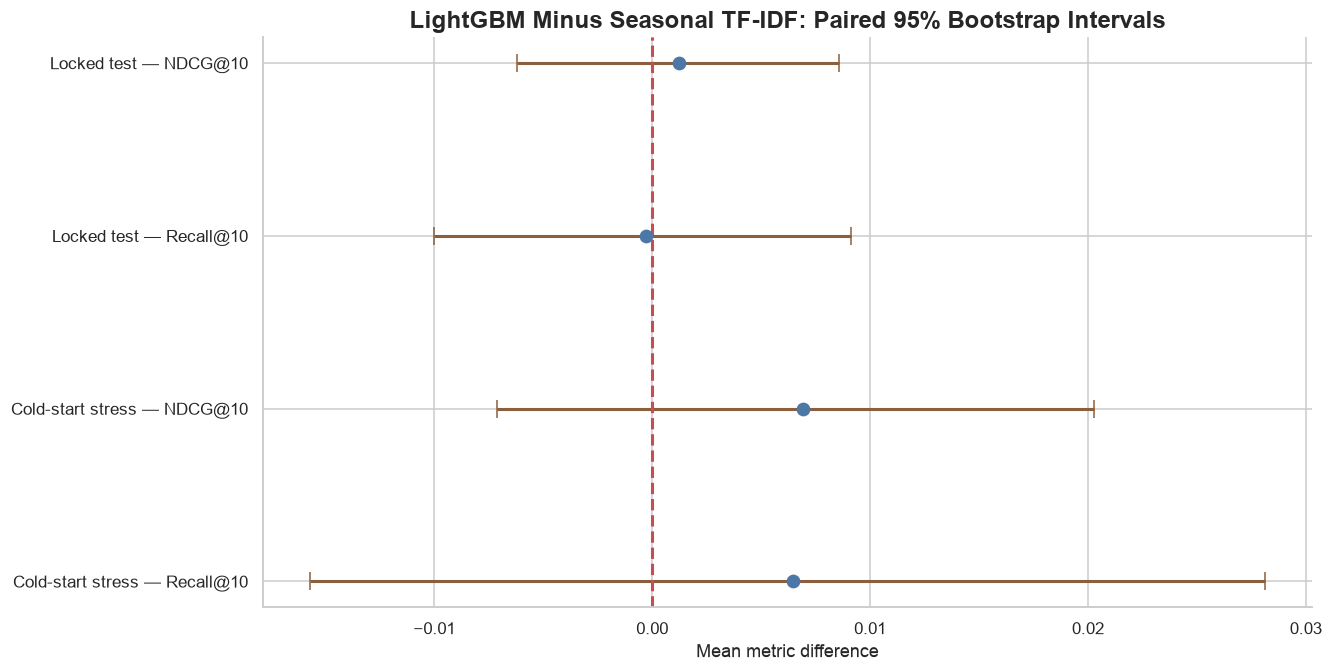

In [9]:
# pyright: reportAny=false, reportUnknownArgumentType=false, reportUnknownMemberType=false, reportUnknownVariableType=false, reportUnusedCallResult=false
interval_records: list[dict[str, str | int | float]] = []
for cohort_key, cohort_label in cohort_labels.items():
    interval_payload = cohort_evidence[cohort_key].lightgbm_minus_seasonal_tfidf
    for metric_key, metric_label in [
        ("ndcg_at_10", "NDCG@10"),
        ("recall_at_10", "Recall@10"),
    ]:
        interval = interval_payload[metric_key]
        interval_records.append(
            {
                "Cohort": cohort_label,
                "Metric": metric_label,
                "Mean difference": interval.mean_delta,
                "Lower 95%": interval.lower_95,
                "Upper 95%": interval.upper_95,
                "Positive resamples": interval.probability_positive,
                "Paired slates": interval.samples,
            }
        )

intervals_df = pd.DataFrame(interval_records)
_ = display(
    intervals_df.style.hide(axis="index").format(
        {
            "Mean difference": "{:+.5f}",
            "Lower 95%": "{:+.5f}",
            "Upper 95%": "{:+.5f}",
            "Positive resamples": "{:.2%}",
            "Paired slates": "{:,}",
        }
    )
)

fig, axis = plt.subplots(figsize=(12, 6), constrained_layout=True)
plot_labels = [f"{record['Cohort']} — {record['Metric']}" for record in interval_records]
positions = np.arange(len(intervals_df))
means = intervals_df["Mean difference"].to_numpy(dtype=np.float64)
lower_errors = means - intervals_df["Lower 95%"].to_numpy(dtype=np.float64)
upper_errors = intervals_df["Upper 95%"].to_numpy(dtype=np.float64) - means

axis.errorbar(
    means,
    positions,
    xerr=np.vstack([lower_errors, upper_errors]),
    fmt="o",
    markersize=8,
    capsize=6,
    linewidth=2,
    color=SEASONLY_COLOURS["blue"],
    ecolor=SEASONLY_COLOURS["brown"],
)
axis.axvline(0, color=SEASONLY_COLOURS["red"], linestyle="--", linewidth=2)
axis.set_yticks(positions, labels=plot_labels)
axis.set_title(
    "LightGBM Minus Seasonal TF-IDF: Paired 95% Bootstrap Intervals",
    fontsize=16,
    fontweight="bold",
)
axis.set_xlabel("Mean metric difference")
axis.set_ylabel("")
axis.invert_yaxis()
plt.show()

### Interpretation of uncertainty

Every interval crosses zero. For locked-test NDCG, the estimated LightGBM improvement is
`+0.00124`, with a 95% interval from `−0.00618` to `+0.00856`. For cold-start NDCG, the
estimate is `+0.00692`, with an interval from `−0.00712` to `+0.02027`.

The data are therefore compatible with a small LightGBM improvement, no meaningful
difference, or a small TF-IDF improvement. LightGBM fails the predefined gate because
neither lower NDCG bound is positive.


## 10. Slice Behaviour and Safety Coverage

Aggregate metrics can hide uneven behaviour. The locked-test evaluation therefore reports
descriptive slices by persona, country and diet. A slice requires at least 30 relevant
slates before interpretation, but these comparisons are still exploratory and are not
adjusted for multiple testing.

A separate safety audit replays eligibility rules for every source and cold-start
candidate. It also records which personas receive at least one slate, distinguishing
ranking quality from catalogue service coverage.


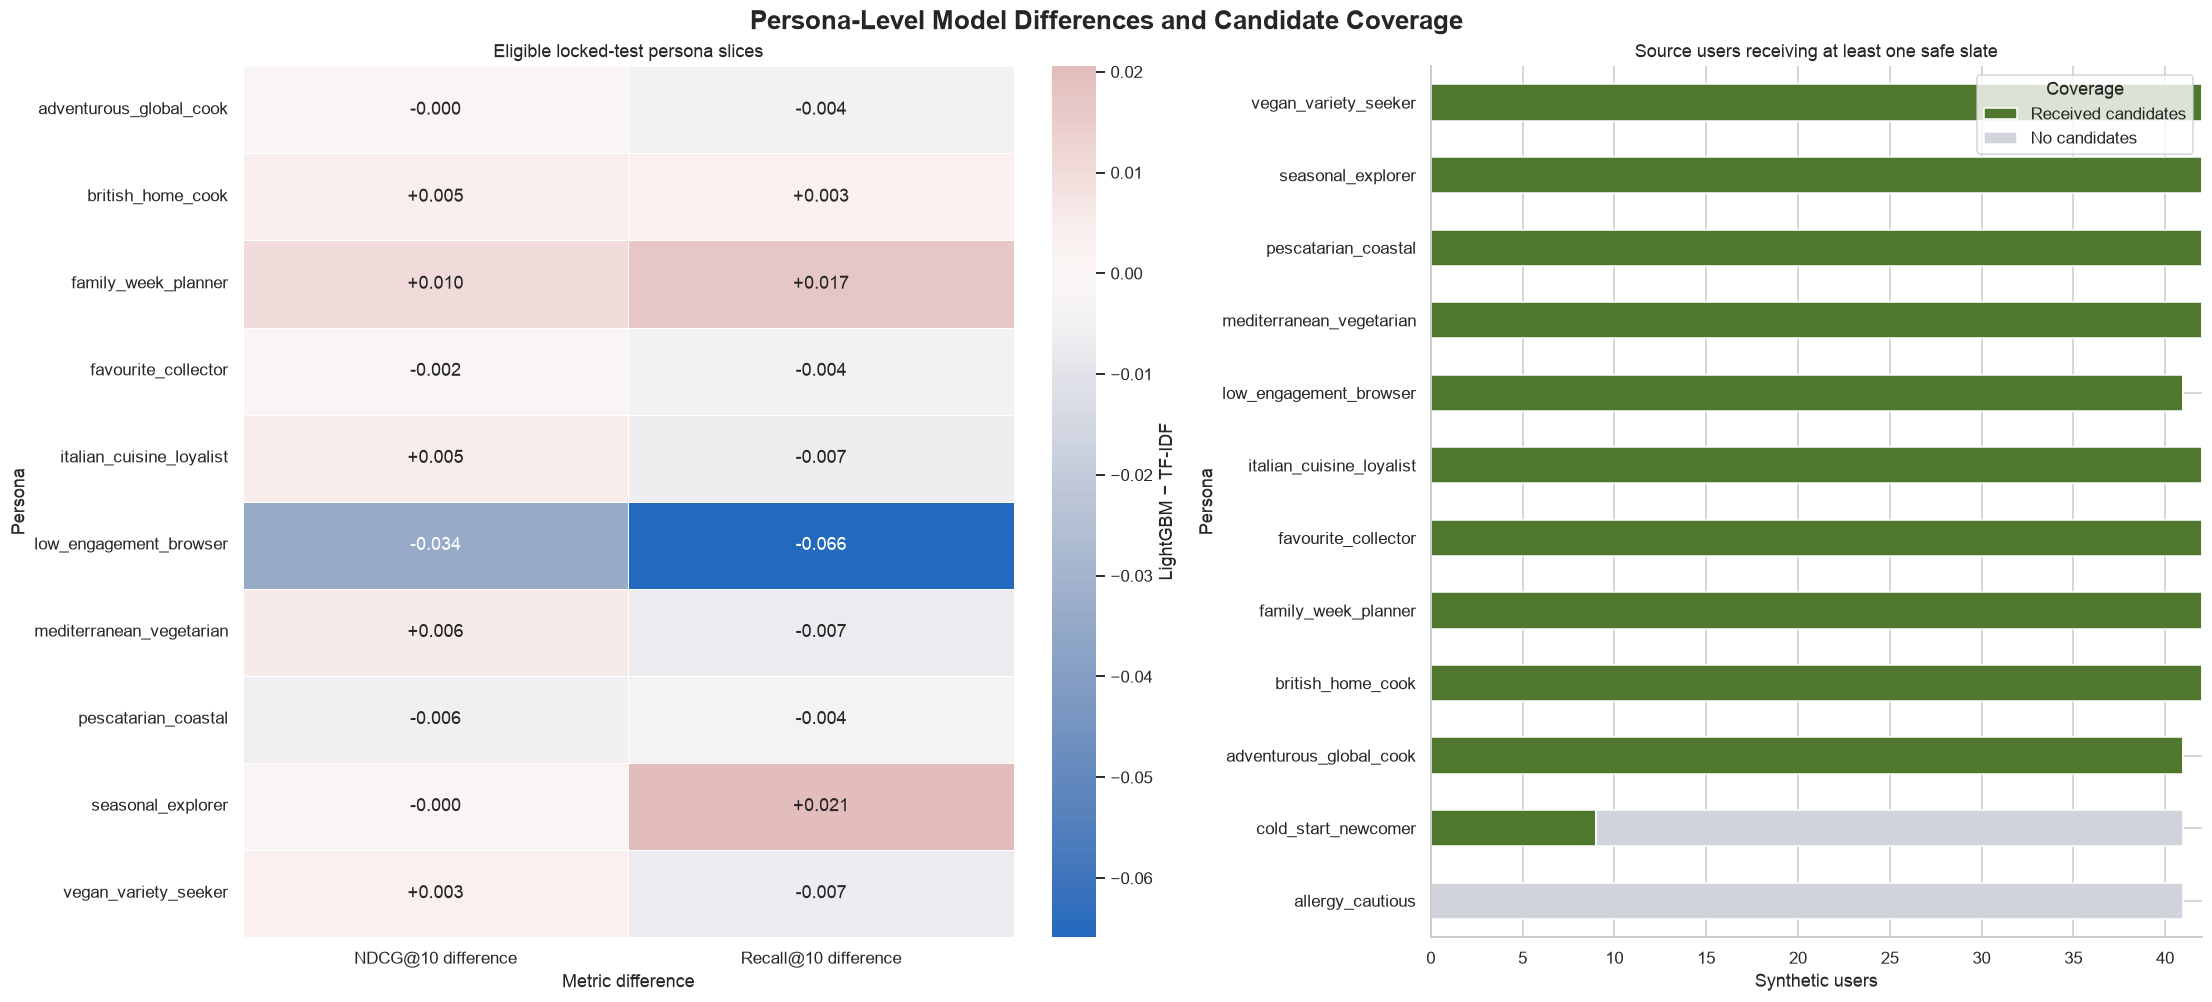

Safety candidates checked: 314,986
Hard-filter violations: 0
Users receiving candidates: 427 / 500


In [10]:
# pyright: reportAny=false, reportUnknownArgumentType=false, reportUnknownMemberType=false, reportUnknownVariableType=false, reportUnusedCallResult=false
persona_slices = robustness_evidence.locked_test.slices.persona_key
eligible_persona_slices = [
    record for record in persona_slices if record.eligible_for_interpretation
]
slice_df = pd.DataFrame(
    {
        "Persona": [record.value for record in eligible_persona_slices],
        "NDCG@10 difference": [
            record.lightgbm_minus_seasonal_tfidf.ndcg_at_10 for record in eligible_persona_slices
        ],
        "Recall@10 difference": [
            record.lightgbm_minus_seasonal_tfidf.recall_at_10 for record in eligible_persona_slices
        ],
    }
).set_index("Persona")

source_audit = robustness_evidence.controls.safety_audits.source_candidates
coverage_records: list[dict[str, str | int]] = []
for persona, counts in source_audit.coverage_by_persona.items():
    coverage_records.append(
        {
            "Persona": persona,
            "Received candidates": counts.users_with_candidates,
            "No candidates": counts.users_without_candidates,
        }
    )
coverage_df = (
    pd.DataFrame(coverage_records)
    .set_index("Persona")
    .sort_values("No candidates", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(20, 9), constrained_layout=True)
fig.suptitle(
    "Persona-Level Model Differences and Candidate Coverage",
    fontsize=17,
    fontweight="bold",
)

sns.heatmap(
    slice_df,
    annot=True,
    fmt="+.3f",
    center=0,
    cmap="vlag",
    linewidths=0.5,
    cbar_kws={"label": "LightGBM − TF-IDF"},
    ax=axes[0],
)
axes[0].set_title("Eligible locked-test persona slices")
axes[0].set_xlabel("Metric difference")
axes[0].set_ylabel("Persona")

coverage_df.plot(
    kind="barh",
    stacked=True,
    color=[SEASONLY_COLOURS["green"], "#D1D5DB"],
    ax=axes[1],
)
axes[1].set_title("Source users receiving at least one safe slate")
axes[1].set_xlabel("Synthetic users")
axes[1].set_ylabel("Persona")
axes[1].legend(title="Coverage")

plt.show()

print(
    "\n".join(
        [
            f"Safety candidates checked: {source_audit.candidates_checked:,}",
            f"Hard-filter violations: {source_audit.violations:,}",
            (
                "Users receiving candidates: "
                + f"{source_audit.users_with_candidates:,} / {source_audit.users:,}"
            ),
        ]
    )
)

### Interpretation of slice and safety findings

LightGBM's direction of change varies by persona. Its largest eligible shortfall is for
`low_engagement_browser`, where NDCG@10 is approximately 0.034 lower and Recall@10 is
approximately 0.066 lower than TF-IDF. Other persona differences are smaller and change
direction. This heterogeneity reinforces the uncertainty shown by the aggregate bootstrap.

The safety audit checks 314,986 source candidates and finds zero eligibility violations.
However, only 427 of 500 users receive a slate. In particular, all 41
`allergy_cautious` users receive no candidates because the imported recipe catalogue lacks
verified `does_not_contain` assessments. This is a catalogue evidence gap, not a reason to
weaken the safety filter.


---

## 11. Final Model Selection

**Seasonal TF-IDF is selected as Seasonly's production recommendation policy.**

The decision is based on the complete evidence rather than the largest point estimate:

- TF-IDF clearly exceeds weighted popularity on locked-test NDCG, Recall and catalogue
  coverage.
- LightGBM has a `+0.00124` locked-test NDCG point difference, but its 95% interval crosses
  zero.
- The independent cold-start NDCG interval also crosses zero.
- Persona slices show mixed behaviour, including a material shortfall for low-engagement
  browsers.
- TF-IDF is deterministic, interpretable and provides a natural cold-start score.
- TF-IDF avoids deploying LightGBM and its additional artefact lifecycle before a reliable
  benefit is demonstrated.
- Both models operate after the same fail-closed safety filters.

LightGBM remains a valid, checksummed **synthetic prototype**, not a failed implementation.
It should be reconsidered only after suitable consented real-user evidence exists and a
new, predefined evaluation gate is approved.


In [11]:
# pyright: reportAny=false, reportUnknownArgumentType=false, reportUnknownMemberType=false, reportUnknownVariableType=false, reportUnusedCallResult=false
decision_gate = robustness_evidence.decision_gate
selected_model = decision_gate.selected_for_section_7
if selected_model != "seasonal_tfidf_content":
    raise ValueError(f"Unexpected frozen model decision: {selected_model}")

final_decision = pd.DataFrame(
    [
        ("Production policy", "Seasonal TF-IDF content"),
        ("Production strategy identifier", "seasonal_tfidf_v1"),
        ("LightGBM status", "Offline synthetic prototype"),
        (
            "Learned-model gate passed",
            decision_gate.learned_model_supported_on_both_cohorts,
        ),
        ("Safety location", "Hard filters before ranking"),
        ("Real-user effectiveness claim", "Not permitted"),
    ],
    columns=["Decision item", "Outcome"],
)
_ = display(final_decision.style.hide(axis="index"))

Decision item,Outcome
Production policy,Seasonal TF-IDF content
Production strategy identifier,seasonal_tfidf_v1
LightGBM status,Offline synthetic prototype
Learned-model gate passed,False
Safety location,Hard filters before ranking
Real-user effectiveness claim,Not permitted


## 12. Application Integration

The chosen scorer is connected to the authenticated FastAPI recommendation feed and the iOS
dashboard:

```text
iOS dashboard
    → GET /api/v1/me/recommendations/feed
    → seasonal, diet and allergen eligibility query
    → seasonal_tfidf_v1 ranking
    → ranked safe recipes and slate identifier
    → consented impression/action events
```

With active personalisation consent, retained opens, favourites and plans construct the
content profile used by cosine similarity. Without consent, the backend does not query
recommendation history and returns deterministic seasonal ordering. Operators can switch
to `seasonal_only_v1` as an emergency rollback without relaxing safety eligibility.

The production API does **not** load the LightGBM artefact. This matches the model decision
established above and avoids presenting a synthetic prototype as deployed effectiveness.


## 13. Social, Ethical and Data-Protection Considerations

Personalised food recommendations can affect health and safety. Seasonly therefore
separates preference ranking from allergen and dietary eligibility, treats unknown
allergen evidence as unsafe, and allows an empty result rather than silently weakening a
constraint.

Personalisation history is processed only after explicit consent. Withdrawal stops
collection and deletes identifiable recommendation events, while automated export and
account deletion controls support data-subject rights. Recommendation logs have a defined
retention period and operational telemetry excludes direct identifiers.

The synthetic generator can reproduce assumptions embedded in persona definitions,
exposure order and action probabilities. Country, cuisine and historical popularity may
also operate as proxies for preferences not directly observed. Slice monitoring,
transparent limitations and human review are therefore required before expanding model
claims.

Finally, the planned 15–20-person private pilot is suitable for usability, safety and
integration testing only. Brief pilot interactions are excluded from model training and
must not be used to claim ranking effectiveness.

**Section sources:** Information Commissioner's Office (2023); Seasonly privacy and
private-pilot evidence.


## 14. Project Summary

This exploration evaluated three approaches to ordering recipes that had already passed
Seasonly's safety and seasonal constraints. The analysis verified the frozen data,
artefact and evaluation checksums; examined 500 synthetic users, 453 recipes and 314,986
candidate rows; and confirmed a leakage-resistant chronological protocol.

Weighted popularity established a simple benchmark. Seasonal TF-IDF combined consented
content similarity with seasonal strength and cuisine preference. LightGBM LambdaRank used
14 contextual and historical features and achieved the highest locked-test point NDCG,
coverage and diversity.

The learned model's NDCG advantage was not statistically supported. Paired bootstrap
intervals crossed zero on both the locked test and the separate 1,000-user cold-start
cohort, while persona slices showed mixed effects. Seasonal TF-IDF was therefore selected
because it provided competitive relevance, broader coverage than popularity, transparent
scoring, deterministic cold-start behaviour and lower operational complexity.

The conclusion is deliberately limited: it validates a synthetic engineering decision,
not real-user benefit. LightGBM remains an offline prototype for future reconsideration
when sufficient lawful and representative evidence becomes available.


## References

All tables, calculations and figures not otherwise attributed are the author's analysis of
the checksummed Seasonly synthetic datasets and immutable recommendation artefacts.

Baumann, J., Castelnovo, A., Cosentini, A., Crupi, R., Inverardi, N. and Regoli, D. (2023)
‘Bias On Demand: Investigating Bias with a Synthetic Data Generator’, *Proceedings of the
Thirty-Second International Joint Conference on Artificial Intelligence*, pp. 7110–7114.
Available at: <https://doi.org/10.24963/ijcai.2023/828>.

Burges, C.J.C. (2010) *From RankNet to LambdaRank to LambdaMART: An overview*. Microsoft
Research Technical Report MSR-TR-2010-82.

Efron, B. and Tibshirani, R.J. (1993) *An introduction to the bootstrap*. New York:
Chapman & Hall.

Information Commissioner's Office (2023) *Guidance on AI and data protection*. Available
at:
<https://ico.org.uk/for-organisations/uk-gdpr-guidance-and-resources/artificial-intelligence/guidance-on-ai-and-data-protection/>
(Accessed: 29 July 2026).

Järvelin, K. and Kekäläinen, J. (2002) ‘Cumulated gain-based evaluation of IR techniques’,
*ACM Transactions on Information Systems*, 20(4), pp. 422–446. Available at:
<https://doi.org/10.1145/582415.582418>.

Kaufman, S., Rosset, S., Perlich, C. and Stitelman, O. (2012) ‘Leakage in data mining:
Formulation, detection, and avoidance’, *ACM Transactions on Knowledge Discovery from
Data*, 6(4), article 15, pp. 1–21. Available at:
<https://doi.org/10.1145/2382577.2382579>.

Ke, G., Meng, Q., Finley, T., Wang, T., Chen, W., Ma, W., Ye, Q. and Liu, T.-Y. (2017)
‘LightGBM: A highly efficient gradient boosting decision tree’, *Advances in Neural
Information Processing Systems*, 30.

Pedregosa, F. *et al.* (2011) ‘Scikit-learn: Machine Learning in Python’, *Journal of
Machine Learning Research*, 12, pp. 2825–2830. Available at:
<https://www.jmlr.org/papers/v12/pedregosa11a.html> (Accessed: 29 July 2026).

Salton, G. and Buckley, C. (1988) ‘Term-weighting approaches in automatic text retrieval’,
*Information Processing & Management*, 24(5), pp. 513–523. Available at:
<https://doi.org/10.1016/0306-4573(88)90021-0>.

Waskom, M.L. (2021) ‘seaborn: statistical data visualization’, *Journal of Open Source
Software*, 6(60), article 3021. Available at:
<https://doi.org/10.21105/joss.03021>.
